In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 47.3 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 70.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.6 MB/s  0:00:00
  Attempting uninstall: pyparsing
    Found existing installation: pyparsing 2.4.7
    Uninstalling pyparsing-2.4.7:
      Successfully uninstalled pyparsing-2.4.7
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


In [4]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 64.4 MB/s  0:00:00


In [7]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 43.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [18]:
!pip install nltk

In [69]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk import word_tokenize
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, classification_report
from collections import Counter

nltk.download('punkt_tab')
nltk.download('stopwords')

task = 0

def preprocess_pandas(data, columns):
    df_ = pd.DataFrame(columns=columns)
    data['Sentence'] = data['Sentence'].str.lower()
    data['Sentence'] = data['Sentence'].replace('[a-zA-Z0-9-_.]+@[a-zA-Z0-9-_.]+', '', regex=True)                      # remove emails
    data['Sentence'] = data['Sentence'].replace('((25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)(\.|$)){4}', '', regex=True)    # remove IP address
    data['Sentence'] = data['Sentence'].str.replace('[^\w\s]','')                                                       # remove special characters
    data['Sentence'] = data['Sentence'].replace('\d', '', regex=True)                                                   # remove numbers
    for index, row in data.iterrows():
        word_tokens = word_tokenize(row['Sentence'])
        filtered_sent = [w for w in word_tokens if not w in stopwords.words('english')]
        df_.loc[len(df_)] = {
            "index": row['index'],
            "Class": row['Class'],
            "Sentence": " ".join(filtered_sent)
        }
    return df_

# If this is the primary file that is executed (ie not an import of another file)
if __name__ == "__main__":
    # get data, pre-process and split
    data = pd.read_csv(r"/home/jovyan/annabell/data/amazon_cells_labelled.txt", delimiter='\t', header=None)
    data.columns = ['Sentence', 'Class']
    data['index'] = data.index                                          # add new column index
    columns = ['index', 'Class', 'Sentence']
    data = preprocess_pandas(data, columns)                             # pre-process
    train_text, val_text, train_labels, val_labels = train_test_split( # split the data into training, validation, and test splits
        data['Sentence'].values.astype('U'),
        data['Class'].values.astype('int32'),
        test_size=0.10,
        random_state=0,
        shuffle=True
    )
  

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [66]:

if __name__ == "__main__":
    # vectorize data using TFIDF and transform for PyTorch for scalability
    word_vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1,2), max_features=50000, max_df=0.5, use_idf=True, norm='l2')
    training_data = word_vectorizer.fit_transform(train_text)        # transform texts to sparse matrix
    training_data = training_data.todense()                             # convert to dense matrix for Pytorch
    vocab_size = len(word_vectorizer.vocabulary_)
    validation_data = word_vectorizer.transform(val_text)
    validation_data = validation_data.todense()
    train_x_tensor = torch.from_numpy(np.array(training_data)).type(torch.FloatTensor)
    train_y_tensor = torch.from_numpy(np.array(train_labels)).long()
    validation_x_tensor = torch.from_numpy(np.array(validation_data)).type(torch.FloatTensor)
    validation_y_tensor = torch.from_numpy(np.array(validation_labels)).long()

Epoch 1: Train Loss=0.6913, Val Loss=0.6833, Acc=0.6400
Epoch 2: Train Loss=0.6652, Val Loss=0.6481, Acc=0.8400
Epoch 3: Train Loss=0.5846, Val Loss=0.5829, Acc=0.8500
Epoch 4: Train Loss=0.4514, Val Loss=0.5094, Acc=0.8500
Epoch 5: Train Loss=0.3059, Val Loss=0.4569, Acc=0.8400
Epoch 6: Train Loss=0.1998, Val Loss=0.4401, Acc=0.8400
Epoch 7: Train Loss=0.1309, Val Loss=0.4320, Acc=0.8400
Final Accuracy: 0.84


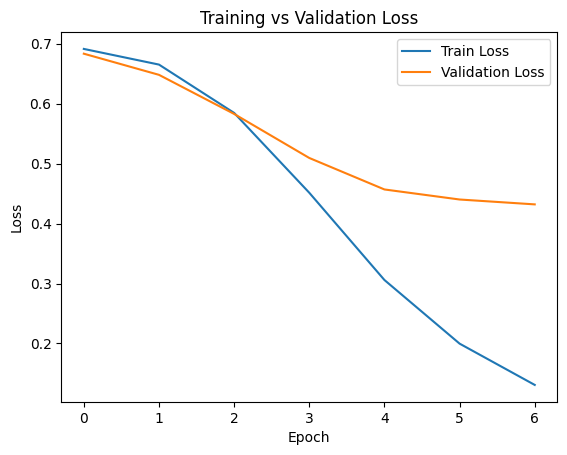

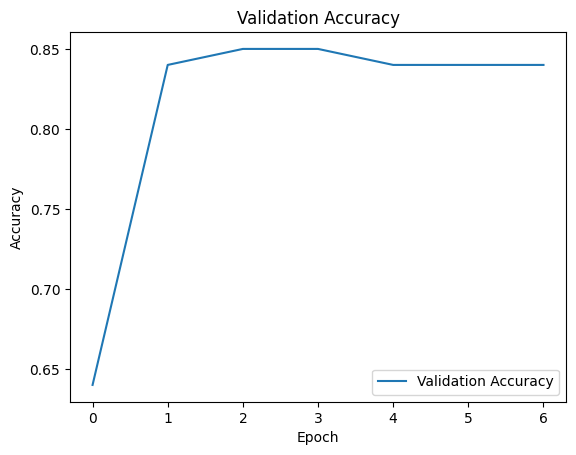

In [68]:
batch_size = 32

train_dataset = TensorDataset(train_x_tensor, train_y_tensor)
val_dataset = TensorDataset(validation_x_tensor, validation_y_tensor)

train_loader1 = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader1 = DataLoader(val_dataset, batch_size=batch_size)

task = 1

class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model1 = SimpleNN(input_dim=vocab_size)

criterion = nn.BCEWithLogitsLoss()   
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)

epochs = 7

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):
    
    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        #Training
        for X_batch, y_batch in train_loader:
            y_batch = y_batch.float().unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        #Validation
        model.eval()
        val_loss = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                y_batch = y_batch.float().unsqueeze(1)

                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

                preds = torch.sigmoid(outputs)
                preds = (preds > 0.5).int()

                all_preds.extend(preds.numpy())
                all_labels.extend(y_batch.numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        acc = accuracy_score(all_labels, all_preds)
        val_accuracies.append(acc)

        print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, Acc={acc:.4f}")

    return train_losses, val_losses, val_accuracies

train_losses_1, val_losses_1, acc_1 = train_model(model1, train_loader1, val_loader1, criterion, optimizer1, epochs)

print("Final Accuracy:", acc_1[-1])
#print("Accuracy:", accuracy_score(all_labels, all_preds))
#print(classification_report(all_labels, all_preds))

plt.figure()
plt.plot(train_losses_1, label="Train Loss")
plt.plot(val_losses_1, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

plt.figure()
plt.plot(acc_1, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")
plt.show()

In [84]:
def make_dict(sentences, max_size=5000):
    counter = Counter()
    for sentence in sentences:
        counter.update(sentence.split())

    word_to_index = {}

    most_common_words = counter.most_common(max_size) #Gives all words in order most to least common

    for i, (word, count) in enumerate(most_common_words): #Connects words to index, most common word gets 2, then 3 etc
        word_to_index[word] = i + 2
        
    word_to_index["<PAD>"] = 0
    word_to_index["<UNK>"] = 1
    return word_to_index


def encode_sentences(sentences, word_to_index, max_len=20): #encodes sentences into list of numbers (keeping order)
    sequences = []
    
    for sentence in sentences:
        tokens = sentence.split()
        seq = []

        for word in tokens: #Replaces each word with either known index, or 1 for unknown word
            if word in word_to_index:
                seq.append(word_to_index[word])
            else:
                seq.append(word_to_index["<UNK>"])

        if len(seq) < max_len: #Pads to max_len
            seq += [word_to_index["<PAD>"]] * (max_len - len(seq))
        else:
            seq = seq[:max_len]

        sequences.append(seq)

    return np.array(sequences)


class LSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=20, hidden_size=128):
        super(LSTM, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)

        x = h[-1] # last hidden state
        x = self.fc(x)

        return x




Epoch 1: Train Loss=0.7003, Val Loss=0.6935, Acc=0.4600
Epoch 2: Train Loss=0.6943, Val Loss=0.6931, Acc=0.5300
Epoch 3: Train Loss=0.6923, Val Loss=0.6972, Acc=0.4700
Epoch 4: Train Loss=0.6961, Val Loss=0.6933, Acc=0.5300
Epoch 5: Train Loss=0.6925, Val Loss=0.6971, Acc=0.4700
Epoch 6: Train Loss=0.6930, Val Loss=0.6947, Acc=0.5300
Epoch 7: Train Loss=0.6855, Val Loss=0.6698, Acc=0.6200
Epoch 8: Train Loss=0.5702, Val Loss=0.5700, Acc=0.7400
Epoch 9: Train Loss=0.4087, Val Loss=0.6130, Acc=0.7400
Epoch 10: Train Loss=0.3111, Val Loss=0.6448, Acc=0.7600
Final Accuracy: 0.76


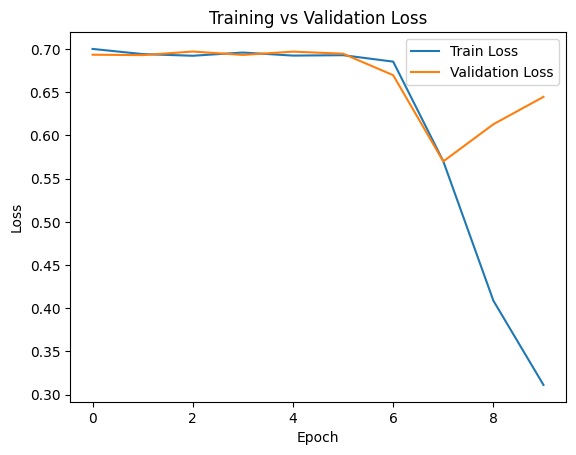

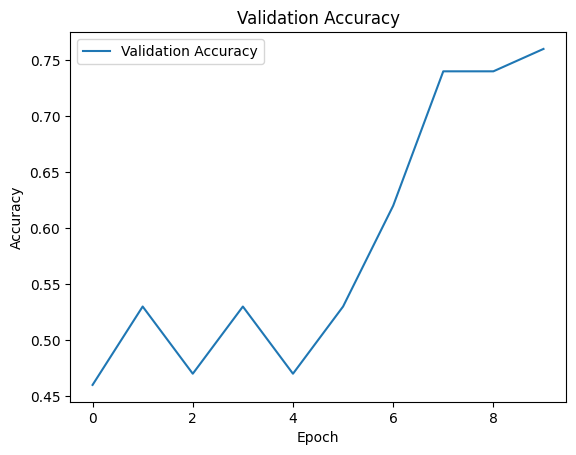

In [95]:
word_to_index = make_dict(train_text) #Gives all words in training_data an index

train_seq = encode_sentences(train_text, word_to_index) #Encodes sentences into list of numbers (keeping order)
val_seq = encode_sentences(val_text, word_to_index)

train_x_tensor = torch.LongTensor(train_seq)
validation_x_tensor = torch.LongTensor(val_seq)

train_y_tensor = torch.LongTensor(train_labels)
validation_y_tensor = torch.LongTensor(val_labels)


#Datasets and loaders
train_dataset = TensorDataset(train_x_tensor, train_y_tensor)
val_dataset = TensorDataset(validation_x_tensor, validation_y_tensor)

train_loader2 = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader2 = DataLoader(val_dataset, batch_size=32)


model2 = LSTM(
    vocab_size=len(word_to_index),
    embed_dim=100,
    hidden_size=128
)

criterion = nn.BCEWithLogitsLoss()
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)


#Training
train_losses_2, val_losses_2, acc_2 = train_model(model2, train_loader2, val_loader2, criterion, optimizer2, epochs=10)

print("Final Accuracy:", acc_2[-1])

plt.figure()
plt.plot(train_losses_2, label="Train Loss")
plt.plot(val_losses_2, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

plt.figure()
plt.plot(acc_2, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")
plt.show()